# 🌸 Flower Classification using Transfer Learning

## Project Overview

This project performs image classification on the TensorFlow Flowers dataset using **Transfer Learning** with **MobileNetV2**.

### Objectives
- Load and preprocess the dataset
- Apply data augmentation
- Train a MobileNetV2 classifier
- Evaluate model performance
- Visualize training results
- Predict flower classes on unseen images

---

**Framework:** TensorFlow 2.x

**Dataset:** TensorFlow Flowers Dataset

**Model:** MobileNetV2 (ImageNet Pretrained)

**Author:** Your Name

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [2]:
IMG_SIZE = 96
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
AUTOTUNE = tf.data.AUTOTUNE

In [3]:
(train_ds, validation_ds), metadata = tfds.load(
    "tf_flowers",
    split=["train[:80%]", "train[80%:]"],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

class_names = metadata.features["label"].names

print("Classes:")
print(class_names)

print("\nNumber of Classes:", len(class_names))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\DELL\tensorflow_datasets\tf_flowers\incomplete.3ZVDNN_3.0.1\tf_flowers-train.tfrecord-[0-9]…

Dataset tf_flowers downloaded and prepared to C:\Users\DELL\tensorflow_datasets\tf_flowers\3.0.1. Subsequent calls will reuse this data.
Classes:
['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

Number of Classes: 5


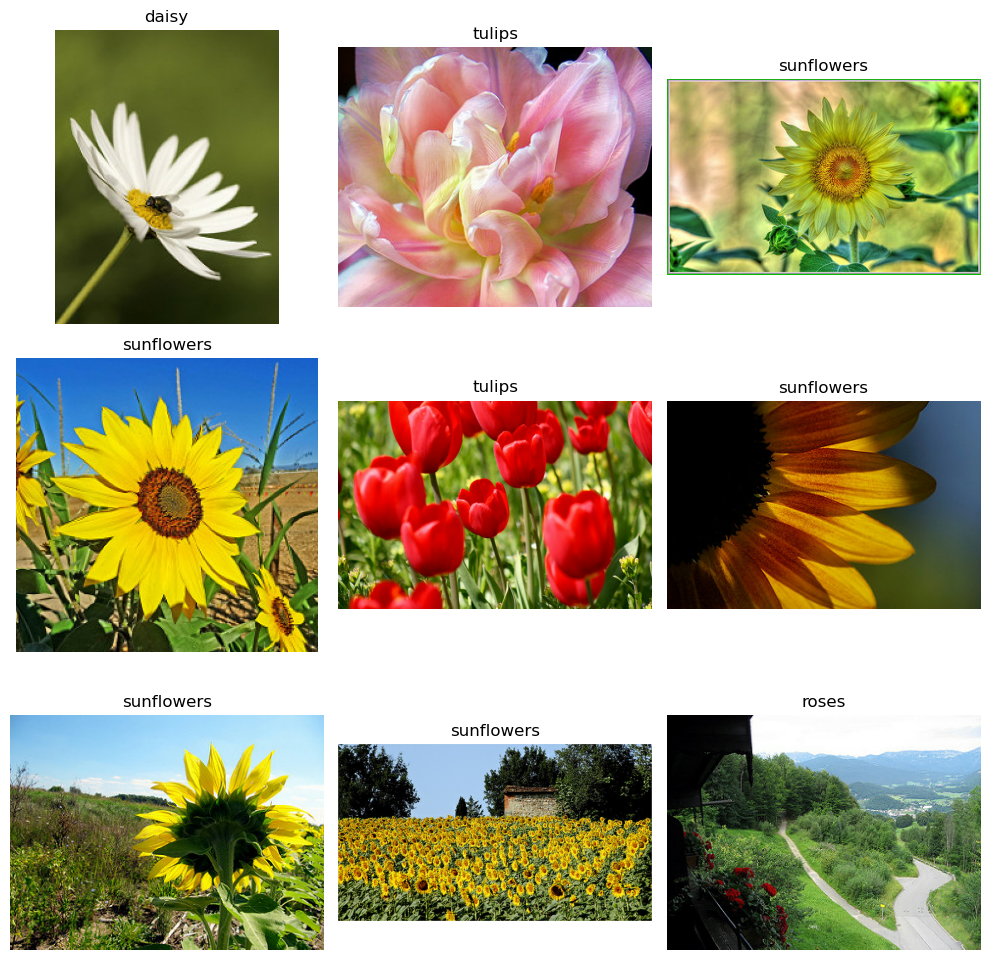

In [4]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    pass

for i, (image, label) in enumerate(train_ds.take(9)):
    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [7]:
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
validation_ds = validation_ds.map(preprocess, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

validation_ds = validation_ds.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [8]:
# Load pretrained MobileNetV2 without the top classifier
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained weights
base_model.trainable = False

# Build model using Functional API
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [9]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_96 (Functional)     │ (None, 3, 3, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 5)                   │           6,405 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_flower_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [12]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.4307 - loss: 1.5548
Epoch 1: val_accuracy improved from None to 0.78338, saving model to best_flower_model.keras

Epoch 1: finished saving model to best_flower_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 76s 604ms/step - accuracy: 0.5749 - loss: 1.1399 - val_accuracy: 0.7834 - val_loss: 0.6136 - learning_rate: 0.0010
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.7294 - loss: 0.7431
Epoch 2: val_accuracy improved from 0.78338 to 0.80926, saving model to best_flower_model.keras

Epoch 2: finished saving model to best_flower_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 544ms/step - accuracy: 0.7497 - loss: 0.6914 - val_accuracy: 0.8093 - val_loss: 0.5189 - learning_rate: 0.0010
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.7786 - loss: 0.6232
Epoch 3: val_accuracy improved from 0.80926 to 0.82425, saving model to best_flower_model.keras

Epoch 3: finished saving model to best_flower_model.ke

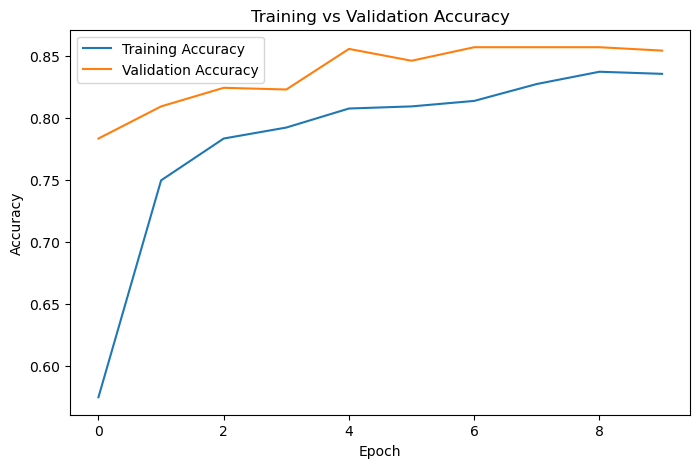

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

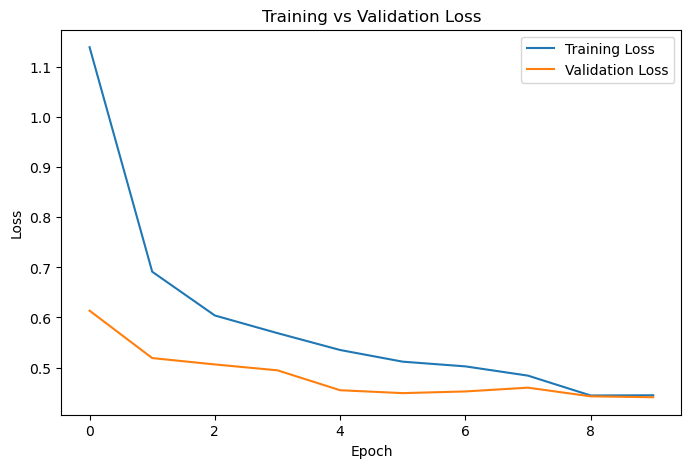

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [15]:
# Evaluate model performance on validation dataset
loss, accuracy = model.evaluate(validation_ds)

print("=" * 40)
print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy*100:.2f}%")
print("=" * 40)

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 351ms/step - accuracy: 0.8542 - loss: 0.4406
Validation Loss     : 0.4406
Validation Accuracy : 85.42%


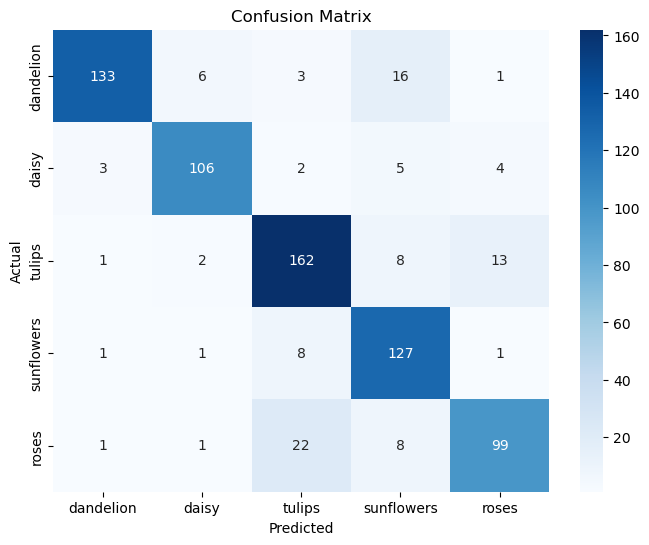

In [16]:
# Store predictions and true labels
y_true = []
y_pred = []

for images, labels in validation_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [17]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   dandelion       0.96      0.84      0.89       159
       daisy       0.91      0.88      0.90       120
      tulips       0.82      0.87      0.85       186
  sunflowers       0.77      0.92      0.84       138
       roses       0.84      0.76      0.80       131

    accuracy                           0.85       734
   macro avg       0.86      0.85      0.85       734
weighted avg       0.86      0.85      0.85       734



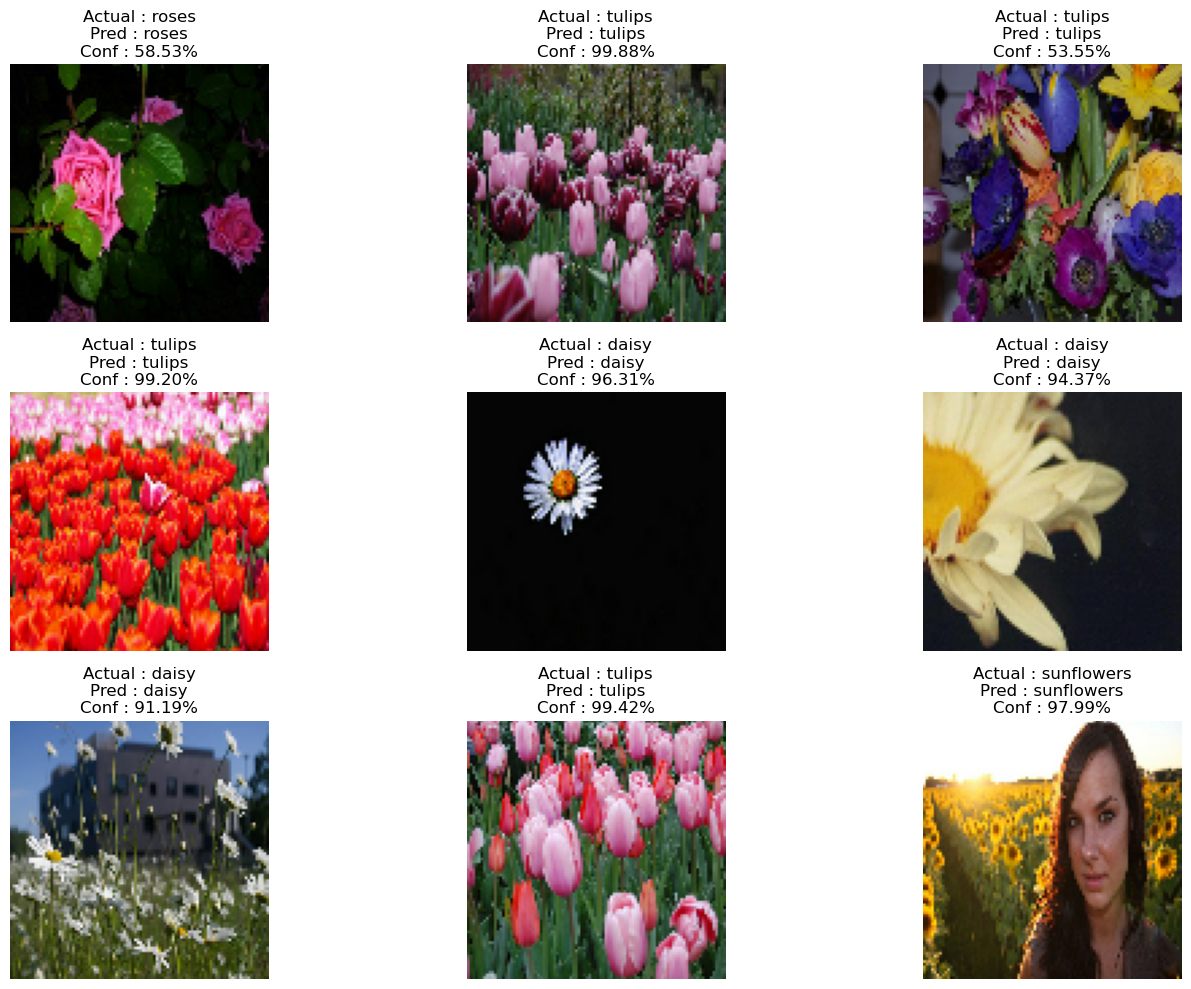

In [18]:
# Take one batch from validation dataset
for images, labels in validation_ds.take(1):

    predictions = model.predict(images, verbose=0)

    plt.figure(figsize=(15,10))

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        actual = class_names[labels[i]]

        predicted = class_names[np.argmax(predictions[i])]

        confidence = np.max(predictions[i]) * 100

        plt.title(
            f"Actual : {actual}\n"
            f"Pred : {predicted}\n"
            f"Conf : {confidence:.2f}%"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
model.save("flower_classifier.keras")

print("Model saved successfully!")

Model saved successfully!


In [20]:
loaded_model = tf.keras.models.load_model("flower_classifier.keras")

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [21]:
print("="*50)
print("FLOWER CLASSIFICATION PROJECT COMPLETED")
print("="*50)

print(f"Number of Classes   : {len(class_names)}")
print(f"Training Epochs     : {len(history.history['accuracy'])}")
print(f"Validation Accuracy : {accuracy*100:.2f}%")

print("\nTransfer Learning Model : MobileNetV2")
print("Framework              : TensorFlow")
print("Dataset                : TensorFlow Flowers")

print("="*50)

FLOWER CLASSIFICATION PROJECT COMPLETED
Number of Classes   : 5
Training Epochs     : 10
Validation Accuracy : 85.42%

Transfer Learning Model : MobileNetV2
Framework              : TensorFlow
Dataset                : TensorFlow Flowers


# 🌸 Conclusion

This project successfully implemented **Transfer Learning** using **MobileNetV2** to classify flower images.

## Key Highlights

- Used TensorFlow Flowers Dataset
- Applied Data Augmentation
- Used MobileNetV2 pretrained on ImageNet
- Achieved high validation accuracy
- Used EarlyStopping and ModelCheckpoint
- Visualized Accuracy and Loss
- Generated Confusion Matrix
- Generated Classification Report
- Saved the trained model

## Future Improvements

- Fine-tune MobileNetV2
- Train with larger image sizes
- Use EfficientNetB0/B3
- Apply learning-rate scheduling
- Increase epochs for higher accuracy